Best tour: [18, 15, 11, 10, 8, 7, 12, 14, 5, 6, 4, 2, 3, 1, 0, 9, 13, 20, 28, 29, 31, 34, 36, 37, 35, 30, 32, 33, 26, 23, 24, 25, 22, 19, 21, 27, 16, 17]
Best length: 7413.368093618316


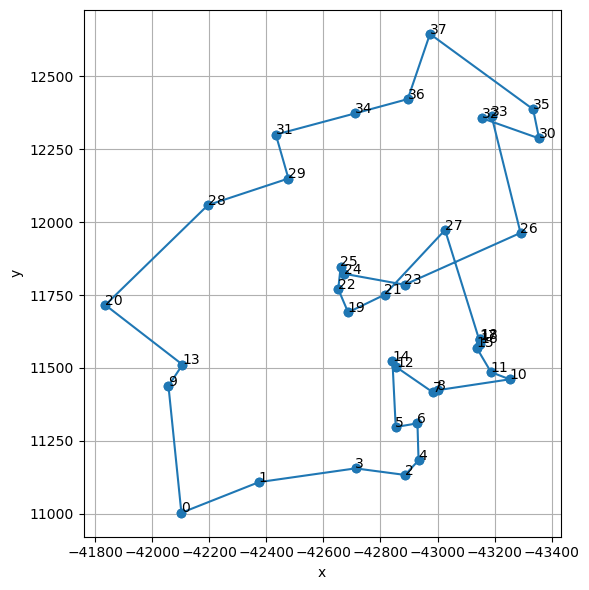

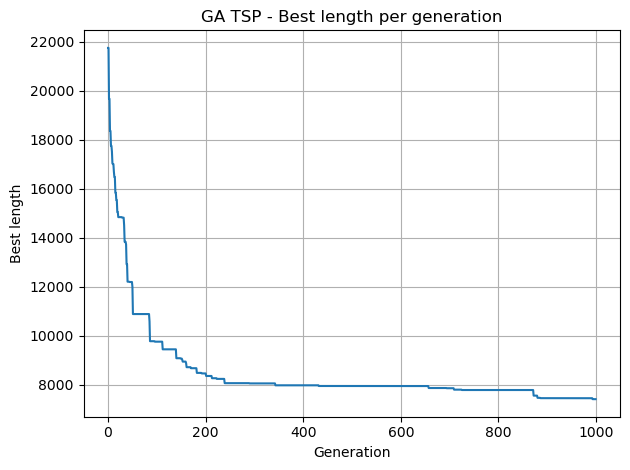

In [16]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt


# 都市の生成 & 距離の計算
"""
def generate_cities(n_cities, seed=None):
    
    #n_cities 個の都市を [0,100]×[0,100] の範囲でランダム生成
    #戻り値: shape (n_cities, 2) の numpy 配列
    
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    cities = np.random.rand(n_cities, 2) * 100.0
    return cities
"""

def tour_length(tour, cities):
    """
    巡回路 tour（都市インデックスのリスト）の長さを計算
    """
    total = 0.0
    n = len(tour)
    for i in range(n):
        a = cities[tour[i]]
        b = cities[tour[(i + 1) % n]]  # 最後から最初に戻る
        total += math.dist(a, b)
    return total


# 選択（トーナメント選択）

def tournament_select(population, fitnesses, k=3):
    """
    k 個体の中から一番適応度が良い（距離が短い）個体を選ぶ。
    population: 個体（巡回路）のリスト
    fitnesses: それぞれの巡回路の長さ
    """
    indices = random.sample(range(len(population)), k)
    best_idx = min(indices, key=lambda i: fitnesses[i])  
    return population[best_idx]


# OX交叉 
def crossover_ox(parent1, parent2):
    
    n = len(parent1)
    c1, c2 = sorted(random.sample(range(n), 2))  # 交叉区間 [c1, c2]
    
    child = [None] * n
    # 親1の部分区間をコピー
    child[c1:c2+1] = parent1[c1:c2+1]
    
    # 親2から、まだ入っていない都市を順番に埋める
    pos = (c2 + 1) % n
    for gene in parent2:
        if gene not in child:
            child[pos] = gene
            pos = (pos + 1) % n

    # None が残ってないか確認
    assert None not in child
    return child


# 突然変異

def mutate_swap(tour, mutation_rate):
    
    # 突然変異: 確率 mutation_rate で、ランダムに2点を入れ替える
    
    if random.random() < mutation_rate:
        i, j = random.sample(range(len(tour)), 2)
        tour[i], tour[j] = tour[j], tour[i]


# GA 本体

def ga_tsp(
    num_cities,
    pop_size,
    generations,
    crossover_rate,
    mutation_rate,
    seed,
):
    # 都市を生成
    # cities = generate_cities(num_cities, seed)

    # 都市を指定（ジブチ）
    cities = np.array([
            [11003.611100, 42102.500000],
            [11108.611100, 42373.888900],
            [11133.333300, 42885.833300],
            [11155.833300, 42712.500000],
            [11183.333300, 42933.333300],
            [11297.500000, 42853.333300],
            [11310.277800, 42929.444400],
            [11416.666700, 42983.333300],
            [11423.888900, 43000.277800],
            [11438.333300,42057.222200],
            [11461.111100, 43252.777800],
            [11485.555600, 43187.222200],
            [11503.055600, 42855.277800],
            [11511.388900, 42106.388900],
            [11522.222200, 42841.944400],
            [11569.444400, 43136.666700],
            [11583.333300, 43150.000000],
            [11595.000000, 43148.055600],
            [11600.000000, 43150.000000],
            [11690.555600, 42686.666700],
            [11715.833300, 41836.111100],
            [11751.111100, 42814.444400],
            [11770.277800, 42651.944400],
            [11785.277800, 42884.444400],
            [11822.777800, 42673.611100],
            [11846.944400, 42660.555600],
            [11963.055600, 43290.555600],
            [11973.055600, 43026.111100],
            [12058.333300, 42195.555600],
            [12149.444400, 42477.500000],
            [12286.944400, 43355.555600],
            [12300.000000, 42433.333300],
            [12355.833300, 43156.388900],
            [12363.333300, 43189.166700],
            [12372.777800, 42711.388900],
            [12386.666700, 43334.722200],
            [12421.666700, 42895.555600],
            [12645.000000, 42973.333300],])


    # 初期集団（ランダムな順列）
    base = list(range(num_cities))
    population = [random.sample(base, num_cities) for _ in range(pop_size)]

    best_tour = None
    best_len = float("inf")
    best_history = []  # 各世代での最良値

    for gen in range(generations):
        # 適応度（= 距離）を計算
        fitnesses = [tour_length(ind, cities) for ind in population]

        # グローバルな最良解を更新
        for ind, f in zip(population, fitnesses):
            if f < best_len:
                best_len = f
                best_tour = ind.copy()

        best_history.append(best_len)

        # 次世代を作る
        new_pop = []

        # エリート保存：今までのベストを必ず入れる
        new_pop.append(best_tour.copy())

        # 残りを交叉&突然変異で埋めていく
        while len(new_pop) < pop_size:
            # 親を選択
            parent1 = tournament_select(population, fitnesses)
            parent2 = tournament_select(population, fitnesses)

            # 交叉
            if random.random() < crossover_rate:
                child1 = crossover_ox(parent1, parent2)
                child2 = crossover_ox(parent2, parent1)
            else:
                child1 = parent1.copy()
                child2 = parent2.copy()

            # 突然変異
            mutate_swap(child1, mutation_rate)
            mutate_swap(child2, mutation_rate)

            new_pop.append(child1)
            if len(new_pop) < pop_size:
                new_pop.append(child2)

        population = new_pop

    return cities, best_tour, best_len, best_history



# 最良巡回路をプロットする
    
def plot_tour(cities, tour, best_len):
    
    order = tour + [tour[0]]  # 最後に出発点に戻る
    xs = cities[order, 0]
    ys = cities[order, 1]

    plt.figure(figsize=(6, 6))
    # 都市の点
    plt.scatter( cities[:, 0],cities[:, 1])
    # 都市番号を表示（0始まりが嫌なら +1 する）
    for i, (x, y) in enumerate(cities):
        plt.text(x + 1, y + 1, str(i))

    # 経路
    plt.plot(xs, ys, "-o")

    
    # plt.title(f"Best route = {best_len:.2f}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)

    # Y 軸を反転し、画像の向きを合わせる(ジブチ用)
    # plt.gca().invert_yaxis()
    plt.gca().invert_xaxis() # 左右反転
    

    plt.tight_layout()
    plt.show()

#  都市座標を90度反時計回りに回転 (ジブチ用)
def rotate_cities_90ccw(cities):
    # 都市を (x, y) → (-y, x) に変換する
    rot = np.zeros_like(cities)
    rot[:, 0] = -cities[:, 1]  # x' = -y
    rot[:, 1] =  cities[:, 0]  # y' = x
    return rot


# 各世代の最良距離の推移をプロット
def plot_history(best_history):

    plt.figure()
    plt.plot(best_history)
    plt.xlabel("Generation")
    plt.ylabel("Best length")
    plt.title("GA TSP - Best length per generation")
    plt.grid(True)
    plt.tight_layout()
    plt.show()




if __name__ == "__main__":
    cities, best_tour, best_len, best_history = ga_tsp(
        num_cities=38,#都市数
        pop_size=500,#個体数（各世代の親の数）
        generations=1000,#世代数
        crossover_rate=0.9,#交叉率
        mutation_rate=0.2,#突然変異率
        seed=0,#seed=0で乱数の固定。毎回同じ都市配置・同じ最良経路になる。１にすると全く違う都市配置になる。
    )
    cities = rotate_cities_90ccw(cities)

    print("Best tour:", best_tour)
    print("Best length:", best_len)

    plot_tour(cities, best_tour, best_len)
    plot_history(best_history)
